In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from matplotlib import pyplot as plt
from src import *

# 1.0 - Classificação do Desempenho Baseado em Acertos na Prova Usando Random Forest

In [2]:
colunas = (
        [f'questao_{i}_LC' for i in range(1, 46)] +
        [f'questao_{i}_CH' for i in range(1, 46)] +
        [f'questao_{i}_CN' for i in range(1, 46)] +
        [f'questao_{i}_MT' for i in range(1, 46)] +
        ['NU_ANO']
    )
df = pd.read_parquet('dados acertos', columns=colunas)

## 1.1 - Criação de Feature e Rótulo

In [3]:
df_rf = calcular_acertos_por_area(df)

In [4]:
df_rf['TOTAL_ACERTOS_GERAL'] = df_rf['ACERTOS_LC'] + df_rf['ACERTOS_MT'] + df_rf['ACERTOS_CH'] + df_rf['ACERTOS_CN'] 

In [5]:
df_rf['CLASSE'] = df_rf.groupby('NU_ANO')['TOTAL_ACERTOS_GERAL'].transform(lambda x: pd.qcut(x, q=3, labels=[1, 2, 3])).astype('Int64')

## 1.2 - Criando uma Amostra

In [6]:
df_reduzido = df_rf.sample(n=100_000, random_state=42)

## 1.3 - Construção da Matriz X e Vetor y

In [11]:
features = (
        [f'questao_{i}_LC' for i in range(1, 46)] +
        [f'questao_{i}_CH' for i in range(1, 46)] +
        [f'questao_{i}_CN' for i in range(1, 46)] +
        [f'questao_{i}_MT' for i in range(1, 46)] +
        ['ACERTOS_LC', 'ACERTOS_CH', 'ACERTOS_CN', 'ACERTOS_MT',
        'NU_ANO']
    )
    
X = df_reduzido[features]
y = df_reduzido['CLASSE']

## 1.4 - Separação em Dados de Treino e Teste

In [12]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 1.5 - Treinando o Modelo

In [13]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

rf.fit(x_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, rf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, rf.predict(x_test))))
print(classification_report(y_test, rf.predict(x_test)))

Ein: 0.0000
Eout: 0.1178
              precision    recall  f1-score   support

         1.0       0.89      0.91      0.90      6898
         2.0       0.81      0.84      0.82      6594
         3.0       0.95      0.90      0.92      6508

    accuracy                           0.88     20000
   macro avg       0.88      0.88      0.88     20000
weighted avg       0.88      0.88      0.88     20000



## 1.6 Treinando com os Melhores Parâmetros

In [14]:
cv_rf = tune_random_forest(x_train, y_train, x_test, y_test, n_iter=10, cv=3, scoring='f1_weighted', random_state=42)

print(cv_rf.best_estimator_)
print('Ein:  %0.4f' % (1 - accuracy_score(y_train, cv_rf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test,  cv_rf.predict(x_test))))
print(classification_report(y_test, cv_rf.predict(x_test)))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
RandomForestClassifier(class_weight='balanced', max_depth=30,
                       min_samples_leaf=10, min_samples_split=50,
                       n_estimators=60, random_state=42)
Ein:  0.0801
Eout: 0.1252
              precision    recall  f1-score   support

         1.0       0.90      0.89      0.90      6898
         2.0       0.80      0.83      0.81      6594
         3.0       0.93      0.90      0.92      6508

    accuracy                           0.87     20000
   macro avg       0.88      0.87      0.88     20000
weighted avg       0.88      0.87      0.88     20000



# 2.0 - Classificação do Desempenho Baseado em Acertos na Prova Usando Decision Tree

## 2.1 - Criando uma Amostra

In [32]:
df_reduzido = df.sample(n=10000, random_state=42)

## 2.2 - Construção da Matriz X e Vetor y

In [33]:
features = (
        [f'questao_{i}_LC' for i in range(1, 46)] +
        [f'questao_{i}_CH' for i in range(1, 46)] +
        [f'questao_{i}_CN' for i in range(1, 46)] +
        [f'questao_{i}_MT' for i in range(1, 46)] +
        ['ACERTOS_LC', 'ACERTOS_CH', 'ACERTOS_CN', 'ACERTOS_MT',
        'NU_ANO']
    )
    
X = df_reduzido[features]
y = df_reduzido['CLASSE']

## 2.3 - Separação em Dados de Treino e Teste

In [34]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 2.4 - Treinando o Modelo

In [35]:
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

print("Ein: %0.4f" % (1 - accuracy_score(y_train, clf.predict(x_train)) ))
print("Eout: %0.4f" % (1 - accuracy_score(y_test, clf.predict(x_test)) ))

print(classification_report(y_test, clf.predict(x_test)))

Ein: 0.0000
Eout: 0.1330
              precision    recall  f1-score   support

         1.0       0.90      0.89      0.89       695
         2.0       0.79      0.81      0.80       662
         3.0       0.91      0.90      0.91       643

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



## 2.5 - Plotando a Árvore

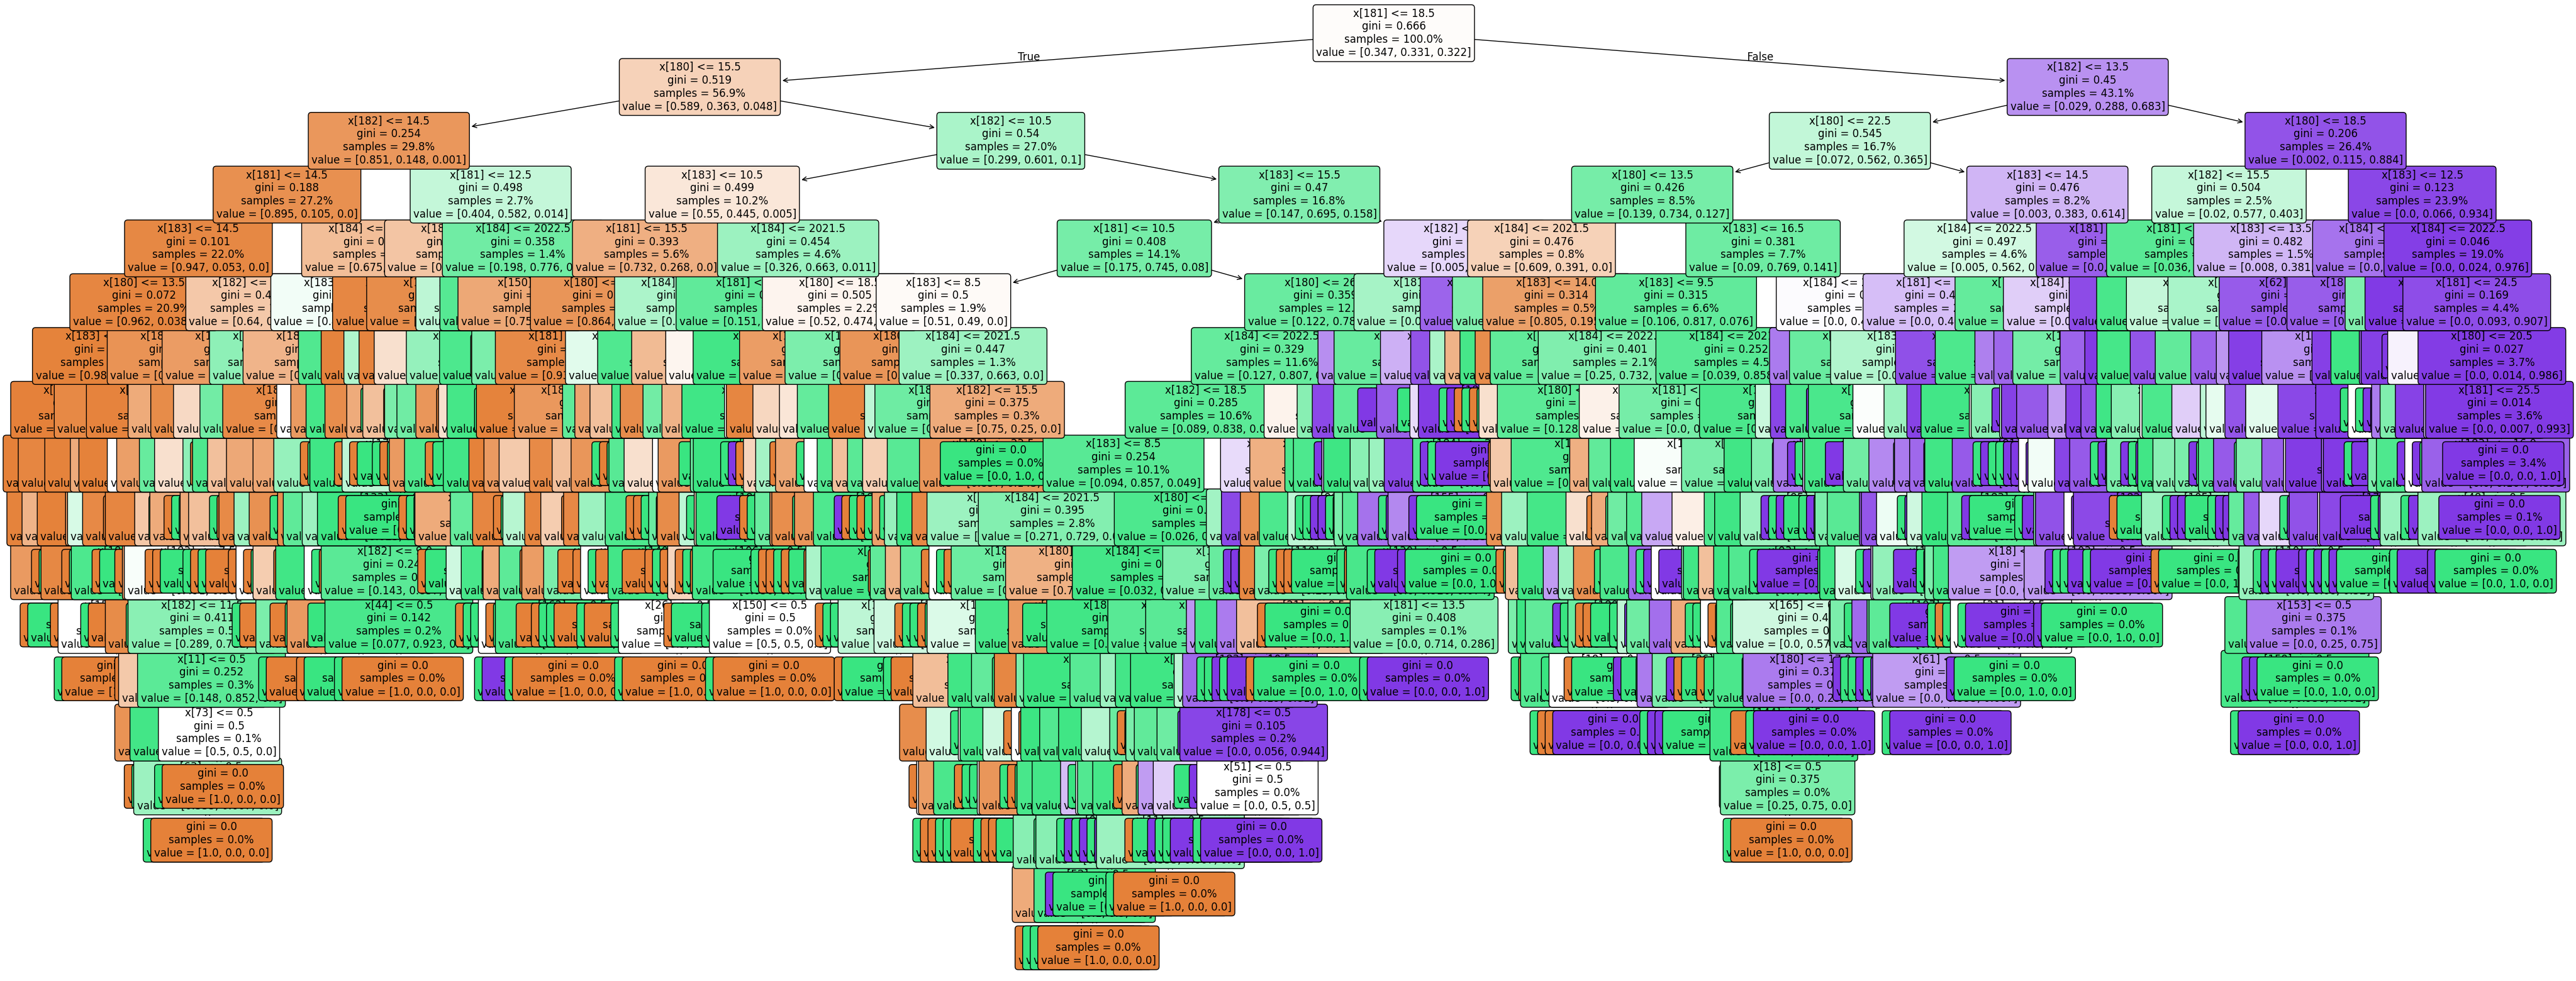

In [36]:
plt.figure(figsize=(50,20))
plot_tree(
    clf,
    filled=True, 
    proportion = True,
    fontsize=12, 
    rounded = True)
plt.show()

## 2.6 - Utilizando o algoritmo de Minimal Cost-Complexity

C:\Users\Micael\AppData\Local\Temp\ipykernel_16272\3411306458.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


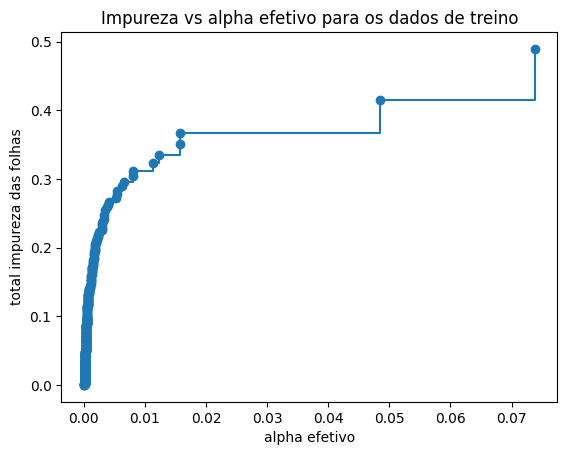

In [37]:
path = clf.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("alpha efetivo")
ax.set_ylabel("total impureza das folhas")
ax.set_title("Impureza vs alpha efetivo para os dados de treino")
fig.show()

## 2.7 - Regularizar o alpha com Minimal Cost-Complexity via cross-validation

In [39]:
alphas_reduzidos = np.unique(np.quantile(path.ccp_alphas, np.linspace(0, 1, 200)))
param_grid = {'ccp_alpha': alphas_reduzidos}

CV_clf = GridSearchCV(estimator=clf, param_grid=param_grid, cv = 5, verbose=2, n_jobs=-1)

CV_clf.fit(x_train, y_train)


print('Ein: %0.4f' % (1 - accuracy_score(y_train, CV_clf.predict(x_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, CV_clf.predict(x_test))))
print(classification_report(y_test, CV_clf.predict(x_test)))

Fitting 5 folds for each of 176 candidates, totalling 880 fits
Ein: 0.0537
Eout: 0.1130
              precision    recall  f1-score   support

         1.0       0.91      0.91      0.91       695
         2.0       0.82      0.84      0.83       662
         3.0       0.94      0.91      0.92       643

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

